In [23]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level=2)


# Activity 2: Reading Binary IRT and 2PL Curves

Use this notebook after Section 2. The goal is to manipulate difficulty and discrimination and explain the resulting ICCs.


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.handson import binary_irt_probability, plot_binary_iccs


## Task 1

Create your own item bank with three items:

- one easy item,
- one medium item,
- one hard item.

Give them different discrimination values.


In [25]:
theta = np.linspace(0.01, 0.99, 300)

student_item_bank = pd.DataFrame(
    [
        {'item': 'item_a', 'difficulty': 0.1, 'discrimination': 10},
        {'item': 'item_b', 'difficulty': 0.5, 'discrimination': 20},
        {'item': 'item_c', 'difficulty': 0.9, 'discrimination': 30},
    ]
)
student_item_bank


,item,difficulty,discrimination
0,item_a,0.1,10
1,item_b,0.5,20
2,item_c,0.9,30


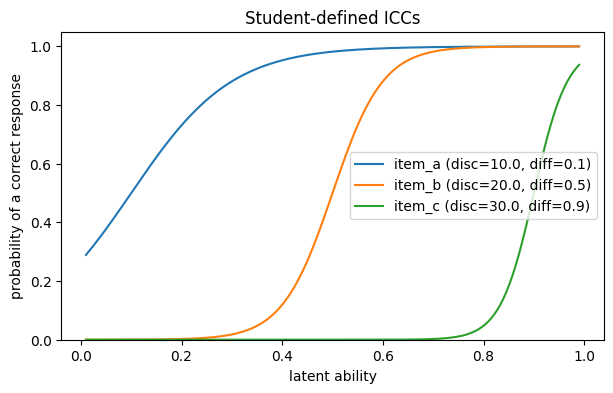

In [26]:
ax = plot_binary_iccs(student_item_bank, theta=theta, title='Student-defined ICCs')
plt.show()


## Task 2

Compute the probability of success for three respondents with abilities `0.2`, `0.6`, and `1` and discurss about the output.


In [27]:
probe_abilities = np.array([0.2, 0.6, 1])
probability_table = pd.DataFrame({'theta': probe_abilities})

for row in student_item_bank.itertuples(index=False):
    probability_table[row.item] = binary_irt_probability(
        theta=probe_abilities,
        difficulty=row.difficulty,
        discrimination=row.discrimination,
    )

probability_table.T.round(3)


,0,1,2
theta,0.200,0.600,1.000
item_a,0.731,0.993,1.000
item_b,0.002,0.881,1.000
item_c,0.000,0.000,0.953


## Task 3

Make one item have **negative discrimination** and inspect the curve. In a teaching discussion, how would you interpret that behavior?


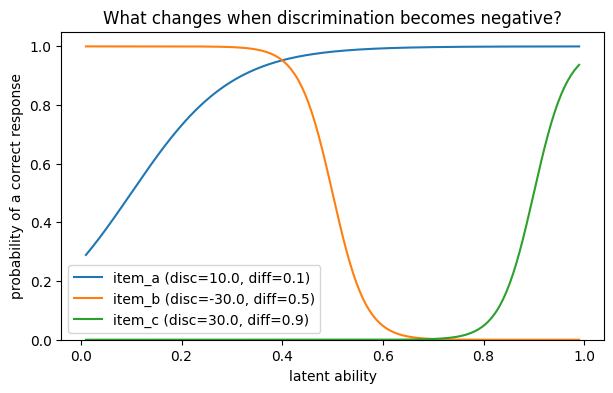

In [29]:
noisy_bank = student_item_bank.copy()
noisy_bank.loc[1, 'discrimination'] = -30

ax = plot_binary_iccs(noisy_bank, theta=theta, title='What changes when discrimination becomes negative?')
plt.show()


## Reflection Questions

1. Which item best separates medium and high ability?
2. Which item is easiest for low-ability respondents?
3. What does a negative discrimination suggest about an item?
4. Why can ICCs be more informative than average accuracy alone?
